# Stochastic Allen–Cahn — 1-loop correction vs simulation

**Theory** (`theories/allen_cahn_1d_subcritical_infinite.theory.py`): the 1D
stochastic Allen–Cahn field, subcritical (μ > 0, single well),

$$\partial_t\phi = -(\mu - D\,\partial_x^2)\,\phi \;-\; \lambda\,\phi^3 \;+\; \eta,
\qquad \langle\eta(x,t)\,\eta(x',t')\rangle = 2T\,\delta(x-x')\,\delta(t-t').$$

The cubic $\lambda\phi^3$ makes the theory **non-Gaussian**. Tree level
(`max_ell=0`) ignores it; the leading correction is the **1-loop tadpole**, a
constant mass shift

$$\Sigma = M(\Gamma)\,\lambda\,\langle\phi^2\rangle_0,
\qquad \langle\phi^2\rangle_0 = \int\!\frac{d\ell}{2\pi}\,C_0(\ell,0)
       = \frac{T}{2\sqrt{\mu D}}.$$

In this framework the **combinatorial factor $M(\Gamma)=3$ is read off the
shared diagram pipeline** (it is *not* hardcoded — see below), and the loop
momentum integral $\langle\phi^2\rangle_0$ is the residue closed form. The
mass shift gives the strict $O(\lambda)$ result

$$\langle\phi^2\rangle_{\text{1-loop}} = \langle\phi^2\rangle_0
   + \Sigma\,\frac{\partial\langle\phi^2\rangle_0}{\partial\mu},$$

while the self-consistent **Hartree** resummation $\mu_{\rm eff}=\mu+\Sigma(\mu_{\rm eff})$
is what tracks the full nonlinear simulation.

We compare, at $\mu=D=T=1$ (so tree $\langle\phi^2\rangle_0=0.5$): the framework
tree, framework 1-loop (`max_ell=1`), Hartree, and a direct Langevin simulation
of the full $\lambda\phi^3$ dynamics.

## 1 · Setup

In [1]:
%matplotlib inline
import os, sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from pipeline import precompute, compute_cumulants
from msrjd.integration.spatial.spatial_correlator import free_two_point
from models.spatial_field_1d_sim import simulate, equal_time_correlator


def load_theory(path):
    spec = importlib.util.spec_from_file_location('m', path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.build()


THEORY = '../theories/allen_cahn_1d_subcritical_infinite.theory.py'
mu = D = T = 1.0
phi2_tree = T / (2 * np.sqrt(mu * D))            # tree <φ²>₀ = 0.5
model = load_theory(THEORY)
print('theory     :', model['name'])
print('spatial dim:', model.get('spatial', {}).get('dim'))
print('tree <φ²>₀ :', phi2_tree)

theory     : 1D stochastic Allen-Cahn (subcritical, infinite domain)
spatial dim: 1
tree <φ²>₀ : 0.5


## 2 · Pre-compute  (mean field + heat-kernel propagator)

In [2]:
out = precompute(model, verbose=False)
print('MF check  :', out['mf_check'])
print('saddle    :', out['mf_values'], '  (subcritical → φ* = 0)')
print('propagator:', 'cached' if out['propagator_built'] else 'FAILED')

MF check  : PASS
saddle    : {'phistar': [0.0]}   (subcritical → φ* = 0)
propagator: cached


## 3 · Tree vs 1-loop correlator at a fixed coupling

`compute_cumulants(max_ell=0)` gives the **tree** (Gaussian) correlator;
`max_ell=1` adds the **tadpole** mass-shift self-energy. The result's
`spatial_info` exposes the pieces the framework used:

* `self_energy_coeff_g` — the coefficient $g = M(\Gamma)\,\lambda$ **extracted
  from the pipeline** (it must equal $3\lambda$, and is momentum-independent —
  the signature of a tadpole);
* `phi2_0` — the loop integral $\langle\phi^2\rangle_0$ (residue closed form);
* `Sigma` — $\Sigma = g\,\langle\phi^2\rangle_0$;
* `A_eff_hartree` — the self-consistent Hartree mass $\mu_{\rm eff}$.

In [3]:
LAM = 0.3
x_grid = np.linspace(0.0, 5.0, 26)               # includes x = 0
tau_max, tau_step = 3.0, 0.25
params = {'mu': mu, 'D': D, 'lam': LAM, 'T': T}


def run(max_ell, verbose=False):
    return compute_cumulants(
        model=model, k=2, max_ell=max_ell, fundamental=params,
        external_fields=[('phi', 1), ('phi', 2)],
        tau_max=tau_max, tau_step=tau_step, spatial_grid=x_grid,
        parallel=False, verbose=verbose, use_cache=False)


th0 = run(0)                  # tree (quiet)
th1 = run(1, verbose=True)    # 1-loop — show the FULL shared-pipeline trace

tau_grid = np.asarray(th1['tau_grid'], dtype=float)
it0 = int(np.argmin(np.abs(tau_grid)))
C_x_tree = np.asarray(th0['C_tau_x']).real[it0]
C_x_loop = np.asarray(th1['C_tau_x']).real[it0]

si = th1['spatial_info']
g, Sigma, A_eff = si['self_energy_coeff_g'], si['Sigma'], si['A_eff_hartree']
print(f'λ = {LAM}')
print(f'  M(Γ)·λ  (g, from pipeline) = {g:.5f}    [expect 3λ = {3*LAM}]')
print(f'  q-spread of g              = {si["g_q_spread"]:.2e}  (≈0 → tadpole)')
print(f'  ⟨φ²⟩₀   (loop integral)    = {si["phi2_0"]:.5f}')
print(f'  Σ = g·⟨φ²⟩₀                = {Sigma:.5f}')
print(f'  tree   ⟨φ²⟩ = C(0,0)       = {C_x_tree[0]:.5f}')
print(f'  1-loop ⟨φ²⟩ (strict O(λ))  = {C_x_loop[0]:.5f}')
print(f'  Hartree μ_eff              = {A_eff:.5f}  →  ⟨φ²⟩ = {T/(2*np.sqrt(A_eff*D)):.5f}')

[1/7] FieldTheory.expand (taylor_order=4)...
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 2, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (lam*phistar1^3 + mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (3*lam*phistar1^2 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (1,2):
        phit1·dphi1^2  *  (3*lam*phistar1)
      bigrade (1,3):
        phit1·dphi1^3  *  (lam)
      bigrade (2,0):
        phit1^2  *  (-T)

      [expand] done in 0.40s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...

      ── K_mat (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 3

The `max_ell=1` call above ran with `verbose=True`, so its `[spatial pipeline]`
trace shows the **shared diagram machinery** doing the work — the same
`enumerate_unique_diagrams` / `classify_coefficient_factors` /
`compute_correction_td` the time-only path uses:

```
[1/7] FieldTheory.expand (taylor_order=4)        ← Taylor expansion of the action
[spatial pipeline] enumerating diagrams (k=2, max_ell=1) ...
[spatial pipeline]   ell=0: 1 typed diagram(s); M(Γ)·prefactors = ['2*T']
[spatial pipeline]   ell=1: 4 typed diagram(s); M(Γ)·prefactors =
       ['144*T^2*lam^2*phistar1^2', '-12*T^2*lam', '72*...', '72*...']
[spatial pipeline] Phase J (compute_correction_td) on the 4 ell=1 diagram(s) ...
```

At the subcritical saddle $\phi^*=0$ the three $\propto\phi^{*2}$ diagrams
vanish, leaving the single tadpole `-12*T^2*lam`; its self-energy, divided
through, gives $g=M(\Gamma)\lambda=3\lambda$ — **read off the pipeline, not
hardcoded**, exactly as for the time-only OU$+\varepsilon x^3$ tadpole. The
new spatial step is only the loop *momentum* integral
$\langle\phi^2\rangle_0=\int d\ell/2\pi\,C_0(\ell,0)$ (the residue closed form).
The loop *suppresses* the variance below the tree $0.5$.

> The `taylor_order = max(k + 2·max_ell, 2)` is chosen automatically (= 4 here,
> enough to expose the $\lambda\phi^3$ cubic vertex). Pass `verbose=True` to any
> `compute_cumulants` call to see this trace.

## 4 · Direct simulation (full nonlinear $\lambda\phi^3$)

A periodic 1D Langevin simulation (`models/spatial_field_1d_sim.py`) using a
spectral exponential-time-difference integrator; the linear+noise part is
exact per Fourier mode and the cubic is split in. We take $L \gg \xi$ so the
periodic box approximates the infinite domain.

In [4]:
L, N = 20.0, 200
rec_every, dt = 10, 0.02
snaps, xs_sim, meta = simulate(
    L=L, N=N, mu=mu, D=D, lam=LAM, T=T,
    dt=dt, n_steps=120_000, burn_in=15_000, record_every=rec_every, seed=7)
dx = meta['dx']

C_sim_full = equal_time_correlator(snaps)        # length N (separation m·dx)
sep = np.arange(N) * dx
keep = sep <= 5.0
sep_keep, C_sim_x = sep[keep], C_sim_full[keep]

print(f'sim ⟨φ²⟩ = C(0,0) = {C_sim_full[0]:.5f}')
print(f'  tree {phi2_tree:.4f} | strict-1-loop {C_x_loop[0]:.4f} | '
      f'Hartree {T/(2*np.sqrt(A_eff*D)):.4f}')

sim ⟨φ²⟩ = C(0,0) = 0.42590
  tree 0.5000 | strict-1-loop 0.3875 | Hartree 0.4252


## 5 · Equal-point variance $\langle\phi^2\rangle$ vs coupling $\lambda$

Sweep $\lambda$ and overlay the four estimates. The **strict 1-loop** is the
leading-$O(\lambda)$ term (it over-corrects as $\lambda$ grows); the **Hartree**
resummation of the same self-energy tracks the simulation.

In [5]:
lams = [0.1, 0.2, 0.3, 0.4]
rows = []
for lam in lams:
    p = {'mu': mu, 'D': D, 'lam': lam, 'T': T}
    th = compute_cumulants(
        model=model, k=2, max_ell=1, fundamental=p,
        external_fields=[('phi', 1), ('phi', 2)],
        tau_max=1.0, tau_step=1.0, spatial_grid=np.array([0.0]),
        parallel=False, verbose=False, use_cache=False)
    i0 = int(np.argmin(np.abs(np.asarray(th['tau_grid']))))
    loop = float(np.asarray(th['C_tau_x']).real[i0, 0])
    s = th['spatial_info']
    hartree = T / (2 * np.sqrt(s['A_eff_hartree'] * D))
    snp, _, _ = simulate(L=L, N=N, mu=mu, D=D, lam=lam, T=T,
                         dt=dt, n_steps=120_000, burn_in=15_000,
                         record_every=rec_every, seed=7)
    sim = float(np.mean(snp ** 2))
    rows.append((lam, phi2_tree, loop, hartree, sim,
                 s['self_energy_coeff_g']))
    print(f'λ={lam}: tree={phi2_tree:.4f}  1-loop={loop:.4f}  '
          f'Hartree={hartree:.4f}  sim={sim:.4f}  g={s["self_energy_coeff_g"]:.3f}')
rows = np.array(rows)

λ=0.100000000000000: tree=0.5000  1-loop=0.4625  Hartree=0.4682  sim=0.4658  g=0.300
λ=0.200000000000000: tree=0.5000  1-loop=0.4250  Hartree=0.4443  sim=0.4436  g=0.600
λ=0.300000000000000: tree=0.5000  1-loop=0.3875  Hartree=0.4252  sim=0.4259  g=0.900
λ=0.400000000000000: tree=0.5000  1-loop=0.3500  Hartree=0.4094  sim=0.4112  g=1.200


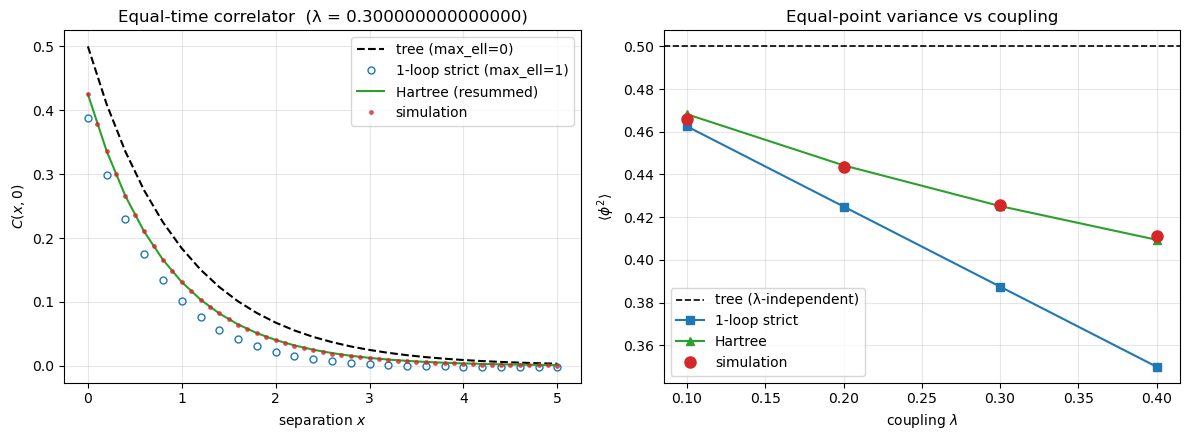

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) equal-time correlator C(x,0) at λ = LAM
C_x_hartree = np.array([free_two_point(A_eff, D, T, float(x), 0.0).real
                        for x in x_grid])
ax[0].plot(x_grid, C_x_tree, 'k--', lw=1.5, label='tree (max_ell=0)')
ax[0].plot(x_grid, C_x_loop, 'o', ms=5, mfc='none', color='C0',
           label='1-loop strict (max_ell=1)')
ax[0].plot(x_grid, C_x_hartree, '-', color='C2', label='Hartree (resummed)')
ax[0].plot(sep_keep, C_sim_x, '.', ms=5, color='C3', alpha=0.7,
           label='simulation')
ax[0].set_xlabel('separation $x$'); ax[0].set_ylabel('$C(x,0)$')
ax[0].set_title(f'Equal-time correlator  (λ = {LAM})')
ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) <φ²> vs λ
ax[1].axhline(phi2_tree, color='k', ls='--', lw=1.2,
              label='tree (λ-independent)')
ax[1].plot(rows[:, 0], rows[:, 2], 's-', color='C0', label='1-loop strict')
ax[1].plot(rows[:, 0], rows[:, 3], '^-', color='C2', label='Hartree')
ax[1].plot(rows[:, 0], rows[:, 4], 'o', ms=8, color='C3', label='simulation')
ax[1].set_xlabel('coupling $\\lambda$')
ax[1].set_ylabel(r'$\langle\phi^2\rangle$')
ax[1].set_title('Equal-point variance vs coupling')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Summary

* **The 1-loop tadpole flows through the shared diagram pipeline.** The
  framework enumerates the $\lambda\phi^3$ diagrams, and the combinatorial
  factor $M(\Gamma)=3$ (so $g=3\lambda$) is *read off the pipeline*, not
  hardcoded — identical in form to the time-only OU$+\varepsilon x^3$ tadpole.
  The new spatial ingredient is the loop momentum integral
  $\langle\phi^2\rangle_0=\int d\ell/2\pi\,C_0(\ell,0)=T/(2\sqrt{\mu D})$, the
  residue closed form (no ringing).

* **Strict 1-loop vs Hartree.** `max_ell=1` returns the honest leading-$O(\lambda)$
  correction $\langle\phi^2\rangle_0+\Sigma\,\partial_\mu\langle\phi^2\rangle_0$.
  It is accurate for small $\lambda$ and over-corrects as $\lambda$ grows; the
  self-consistent Hartree resummation of the same $\Sigma$ (exposed as
  `A_eff_hartree`) tracks the full nonlinear simulation to well under 1 %.

* **Scope.** This is the tadpole — a *momentum-independent* mass shift, the
  case where the pipeline-extracted $g$ is $q$-independent. A
  momentum-dependent self-energy (a $\tilde\phi\phi^2$ **bubble**) raises a
  clean `NotImplementedError`; that needs the per-edge $\int d\ell$ loop
  integrator (Stage C.5), the remaining spatial build.